In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import asyncpg
import asyncio

async def get_conn():
    return await asyncpg.connect(
        host='localhost',
        port=5432,
        database='ipl_analytics',
        user='postgres',
        password='postgres'
    )

# Test connection
async def test():
    conn = await get_conn()
    print("Connected!")
    await conn.close()

await test()

Connected!


In [3]:
async def powerplay_runs():
    conn = await get_conn()
    
    query = """
        SELECT 
            m.season,
            t.team_name,
            COUNT(DISTINCT d.match_id) as matches,
            SUM(d.runs_total) as total_runs,
            COUNT(*) as total_balls,
            ROUND(SUM(d.runs_total) * 6.0 / COUNT(*), 2) as run_rate,
            ROUND(SUM(d.runs_total)::numeric / COUNT(DISTINCT d.match_id), 2) as avg_pp_score
        FROM deliveries d
        JOIN matches m ON d.match_id = m.match_id
        JOIN teams t ON d.batting_team_id = t.team_id
        WHERE d.over_num BETWEEN 0 AND 5
        AND m.season IN ('2021', '2022', '2023', '2024', '2025', '2026')
        AND d.is_super_over = FALSE
        GROUP BY t.team_name, m.season
        ORDER BY run_rate DESC
    """
    
    rows = await conn.fetch(query)
    await conn.close()
    return pd.DataFrame(rows, columns=['season','team', 'matches', 'total_runs', 'total_balls', 'run_rate', 'avg_pp_score'])

df_pp = await powerplay_runs()
df_pp

,season,team,matches,total_runs,total_balls,run_rate,avg_pp_score
0,2026,Punjab Kings,6,456,230,11.90,76.00
1,2026,Rajasthan Royals,8,552,305,10.86,69.00
2,2024,Sunrisers Hyderabad,16,1073,605,10.64,67.06
3,2024,Kolkata Knight Riders,14,930,531,10.51,66.43
4,2026,Sunrisers Hyderabad,8,542,310,10.49,67.75
5,2025,Rajasthan Royals,14,914,525,10.45,65.29
6,2026,Royal Challengers Bengaluru,7,436,258,10.14,62.29
7,2024,Delhi Capitals,14,897,531,10.14,64.07
8,2025,Punjab Kings,18,1075,668,9.66,59.72
9,2024,Royal Challengers Bengaluru,15,876,552,9.52,58.40


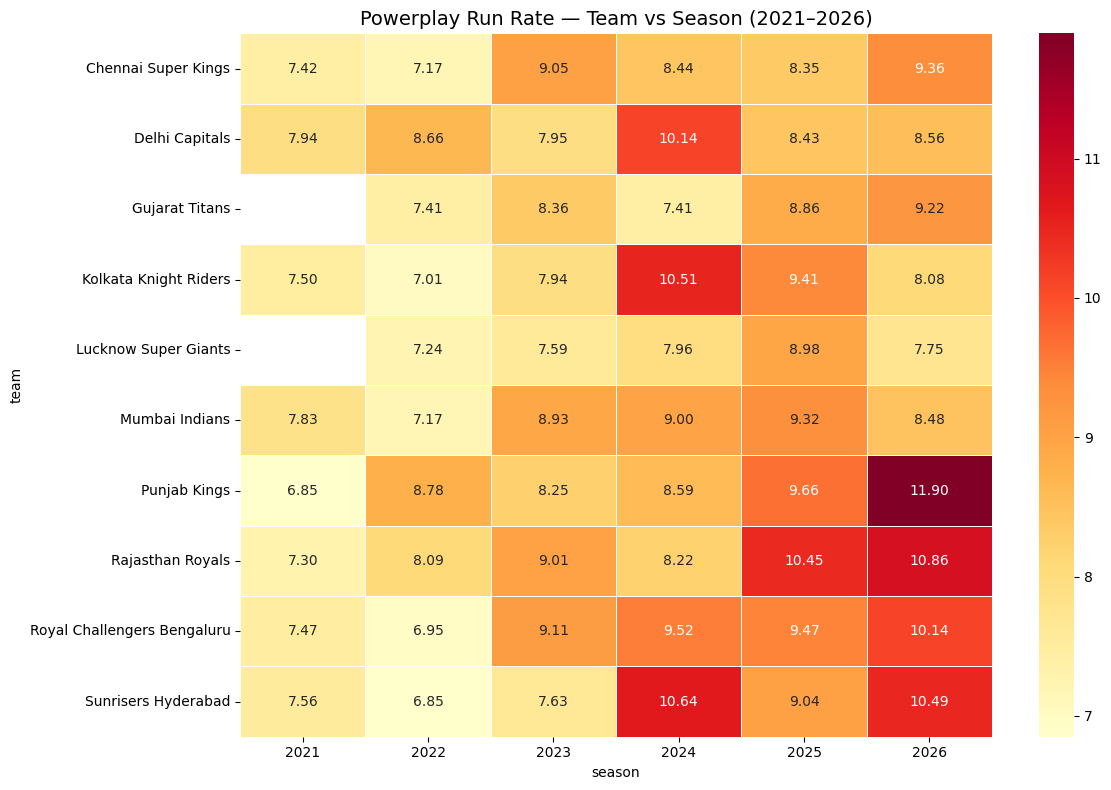

In [4]:
pivot = df_pp.pivot_table(index='team', columns='season', values='run_rate')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot.astype(float), annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Powerplay Run Rate — Team vs Season (2021–2026)', fontsize=14)
plt.tight_layout()
plt.show()

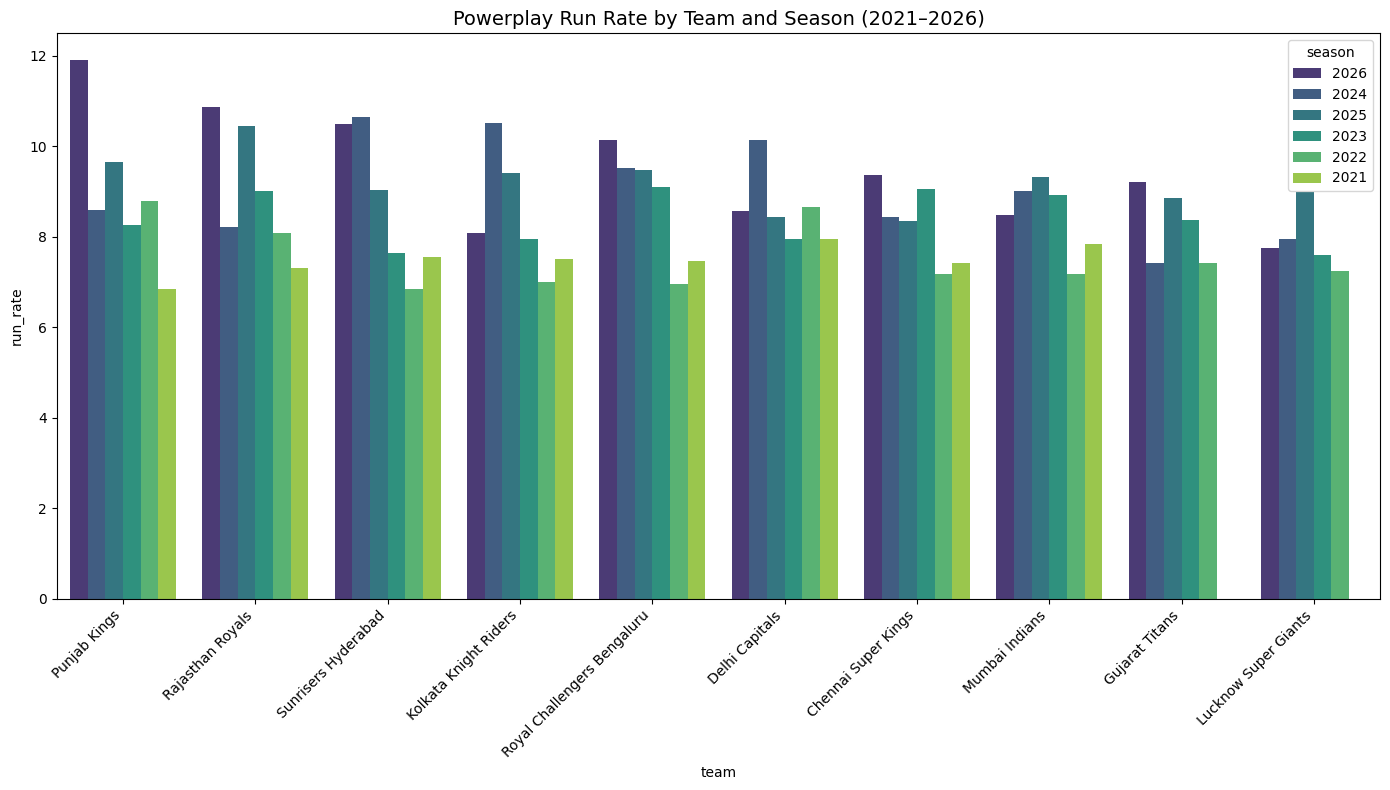

In [5]:
plt.figure(figsize=(14, 8))
sns.barplot(data=df_pp, x='team', y='run_rate', hue='season', palette='viridis')
plt.title('Powerplay Run Rate by Team and Season (2021–2026)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

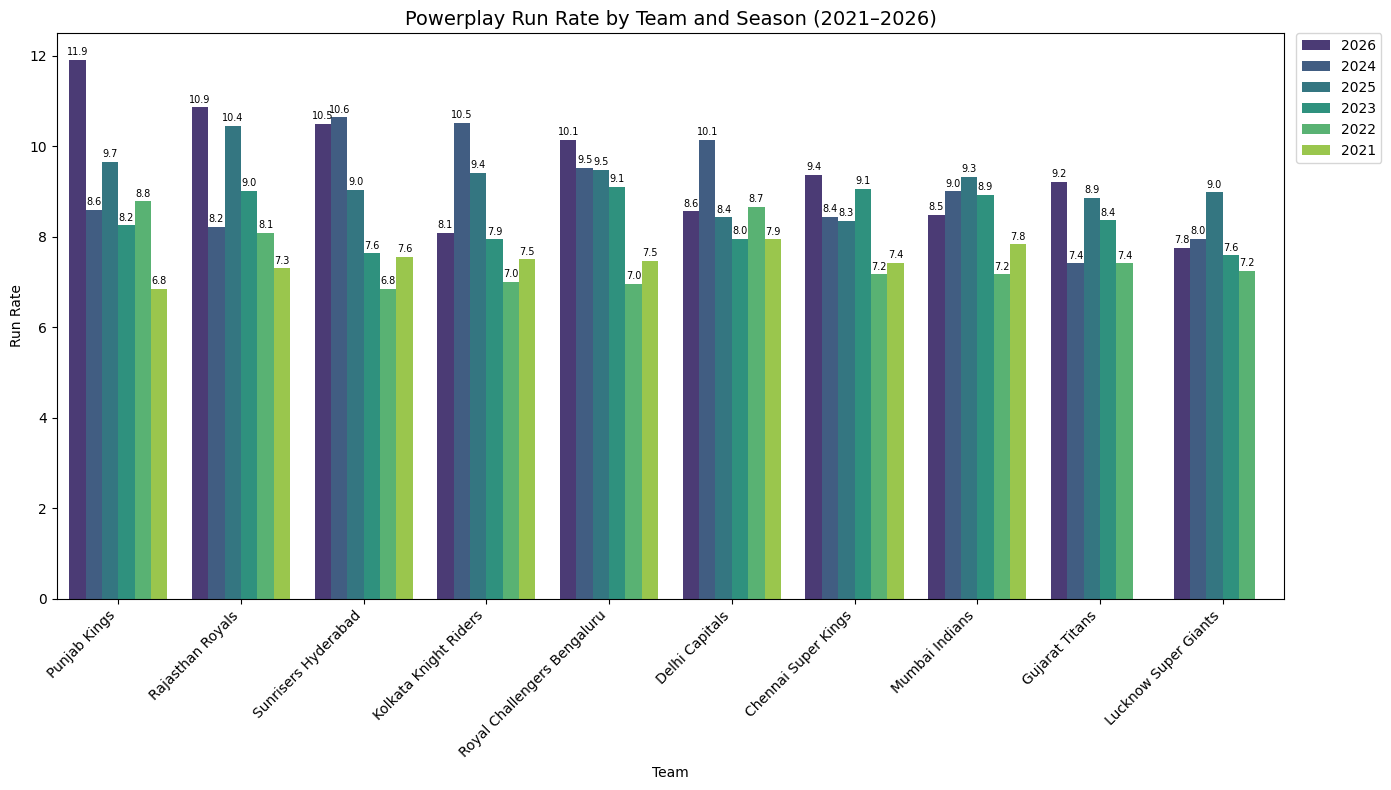

In [7]:
plt.figure(figsize=(14, 8))
ax = sns.barplot(data=df_pp, x='team', y='run_rate', hue='season', palette='viridis')
plt.title('Powerplay Run Rate by Team and Season (2021–2026)', fontsize=14)
plt.xlabel('Team')
plt.ylabel('Run Rate')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=7, padding=2)

# Move legend outside
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

In [23]:
async def death_over_economy():
    conn = await get_conn()
    
    # query = """
    #     SELECT 
    #         p.player_name,
    #         m.season,
    #         COUNT(DISTINCT d.match_id) as matches,
    #         COUNT(*) as balls,
    #         SUM(d.runs_total) as runs_conceded,
    #         ROUND(SUM(d.runs_total) * 6.0 / COUNT(*), 2) as economy,
    #         SUM(CASE WHEN d.is_wicket THEN 1 ELSE 0 END) as wickets,
    #         ROUND(SUM(CASE WHEN d.is_wicket THEN 1 ELSE 0 END) * 6.0 / COUNT(*) * 100, 2) as wicket_rate,
    #         ROUND(COUNT(*) * 1.0 / 
    #               CASE WHEN m.season = '2026' THEN 30 
    #               ELSE 60 END, 2) as sample_reliability
    #     FROM deliveries d
    #     JOIN matches m ON d.match_id = m.match_id
    #     JOIN players p ON d.bowler_id = p.player_id
    #     WHERE d.over_num BETWEEN 15 AND 19
    #     AND m.season IN ('2021', '2022', '2023', '2024', '2025', '2026')
    #     AND d.is_super_over = FALSE
    #     AND (d.extra_type NOT IN ('wides', 'noballs') OR d.extra_type IS NULL)
    #     GROUP BY p.player_name, m.season
    #     HAVING COUNT(*) >= CASE 
    #         WHEN m.season = '2026' THEN 30
    #         ELSE 60
    #     END
    #     ORDER BY season DESC, economy ASC
    # """
    query = """
        SELECT 
            p.player_name,
            CASE 
                WHEN d.batting_team_id = m.team1_id THEN t2.team_name
                ELSE t1.team_name
            END as bowling_team,
            m.season,
            COUNT(DISTINCT d.match_id) as matches,
            COUNT(*) as balls,
            SUM(d.runs_total) as runs_conceded,
            ROUND(SUM(d.runs_total) * 6.0 / COUNT(*), 2) as economy,
            SUM(CASE WHEN d.is_wicket THEN 1 ELSE 0 END) as wickets,
            ROUND(SUM(CASE WHEN d.is_wicket THEN 1 ELSE 0 END) * 6.0 / COUNT(*) * 100, 2) as wicket_rate,
            ROUND(COUNT(*) * 1.0 / 
                CASE WHEN m.season = '2026' THEN 30 
                ELSE 60 END, 2) as sample_reliability
        FROM deliveries d
        JOIN matches m ON d.match_id = m.match_id
        JOIN players p ON d.bowler_id = p.player_id
        JOIN teams t1 ON m.team1_id = t1.team_id
        JOIN teams t2 ON m.team2_id = t2.team_id
        WHERE d.over_num BETWEEN 15 AND 19
        AND m.season IN ('2021', '2022', '2023', '2024', '2025', '2026')
        AND d.is_super_over = FALSE
        AND (d.extra_type NOT IN ('wides', 'noballs') OR d.extra_type IS NULL)
        GROUP BY 
            p.player_name,
            CASE 
                WHEN d.batting_team_id = m.team1_id THEN t2.team_name
                ELSE t1.team_name
            END,
            m.season
        HAVING COUNT(*) >= CASE 
            WHEN m.season = '2026' THEN 30
            ELSE 60
        END
        ORDER BY m.season DESC, economy ASC;
    """
    
    rows = await conn.fetch(query)
    await conn.close()
    return pd.DataFrame(rows, columns=['bowler', 'team', 'season', 'matches', 'balls', 'runs_conceded', 'economy', 'wickets', 'wicket_rate', 'sample_reliability'])

df_death = await death_over_economy()
df_death

,bowler,team,season,matches,balls,runs_conceded,economy,wickets,wicket_rate,sample_reliability
0,B Kumar,Royal Challengers Bengaluru,2026,7,72,89,7.42,8,66.67,2.40
1,L Ngidi,Delhi Capitals,2026,6,64,81,7.59,5,46.88,2.13
2,Brijesh Sharma,Rajasthan Royals,2026,4,34,43,7.59,4,70.59,1.13
3,JC Archer,Rajasthan Royals,2026,5,42,55,7.86,3,42.86,1.40
4,A Kamboj,Chennai Super Kings,2026,6,64,85,7.97,8,75.00,2.13
...,...,...,...,...,...,...,...,...,...,...
142,K Rabada,Delhi Capitals,2021,14,102,177,10.41,6,35.29,1.70
143,M Prasidh Krishna,Kolkata Knight Riders,2021,10,81,141,10.44,4,29.63,1.35
144,B Kumar,Sunrisers Hyderabad,2021,10,90,157,10.47,2,13.33,1.50
145,AD Russell,Kolkata Knight Riders,2021,6,60,105,10.50,8,80.00,1.00


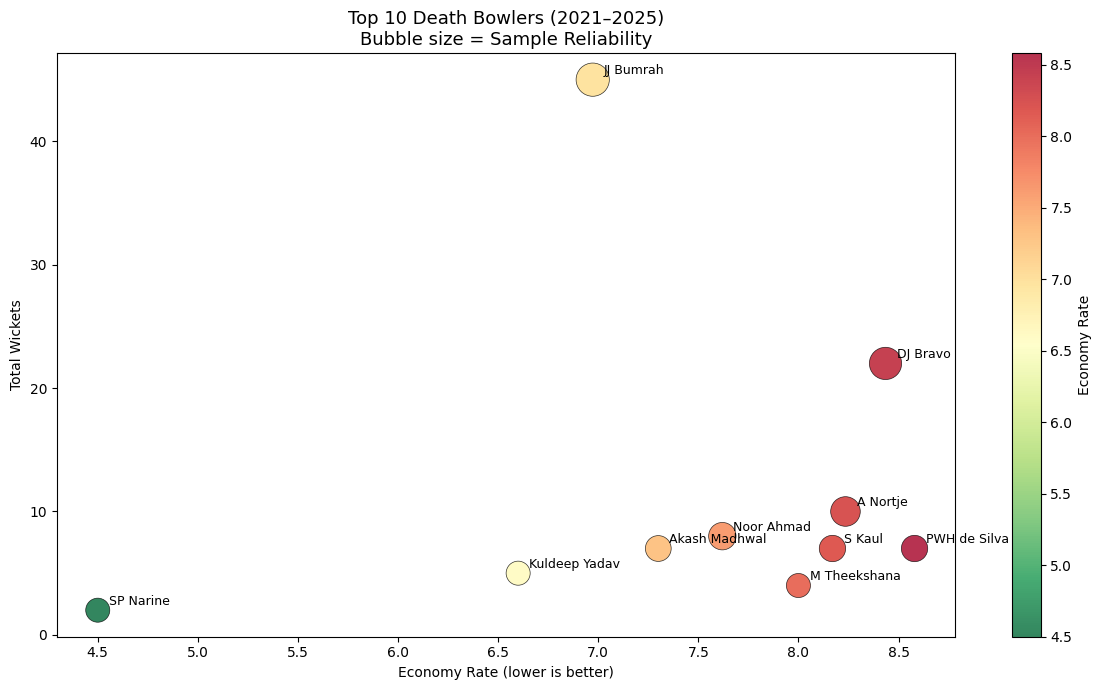

In [26]:
# Top 10 by economy — exclude 2026 for fairness
df_top10 = df_death[df_death['season'] != '2026'].groupby('bowler').agg(
    economy=('economy', 'mean'),
    wickets=('wickets', 'sum'),
    sample_reliability=('sample_reliability', 'mean')
).reset_index().sort_values('economy').head(10)

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df_top10['economy'].values,
    df_top10['wickets'].values,
    s=df_top10['sample_reliability'].values.astype(float) * 300,
    c=df_top10['economy'].values.astype(float),
    cmap='RdYlGn_r',
    alpha=0.8,
    edgecolors='black',
    linewidths=0.5
)

for _, row in df_top10.iterrows():
    plt.annotate(
        row['bowler'],
        (row['economy'], row['wickets']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=9
    )

plt.colorbar(scatter, label='Economy Rate')
plt.xlabel('Economy Rate (lower is better)')
plt.ylabel('Total Wickets')
plt.title('Top 10 Death Bowlers (2021–2025)\nBubble size = Sample Reliability', fontsize=13)
plt.tight_layout()
plt.show()

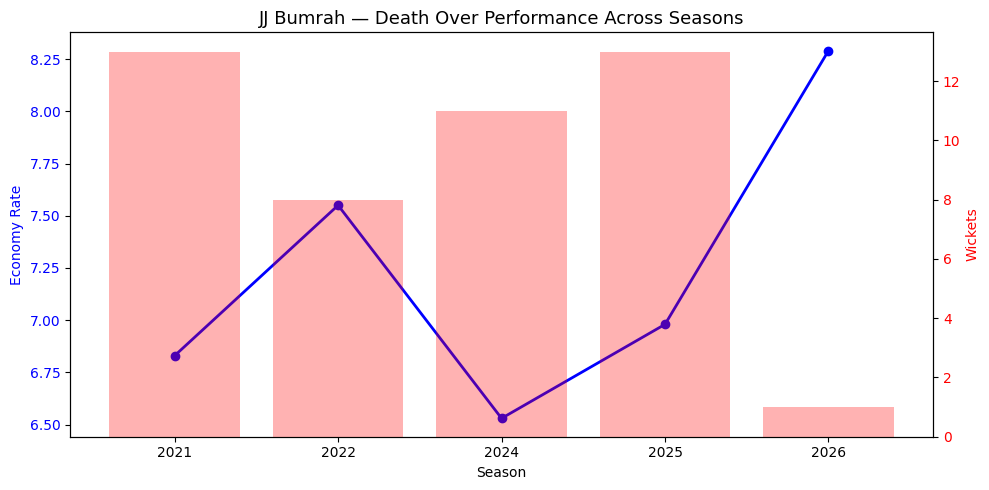

In [33]:
df_bumrah = df_death[df_death['bowler'] == 'JJ Bumrah'].sort_values('season')

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_bumrah['season'], df_bumrah['economy'], 
         color='blue', marker='o', linewidth=2, label='Economy')
ax1.set_ylabel('Economy Rate', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.bar(df_bumrah['season'], df_bumrah['wickets'], 
        alpha=0.3, color='red', label='Wickets')
ax2.set_ylabel('Wickets', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('JJ Bumrah — Death Over Performance Across Seasons', fontsize=13)
ax1.set_xlabel('Season')
fig.tight_layout()
plt.show()